# Lightweight & Lightning Fast Content Safety Classifier
### Author:  <a href="https://www.linkedin.com/in/nancynwei/">Nancy N. Wei</a>
#### Project completion date:  January 24, 2026

## Summary

This project implements a lightweight, high-performance content safety classifier designed to detect Personal Identifiable Information (PII such as email and address) and Harmful Content (any content referring to illegal drugs and bioweapons).  By fine-tuning a 1.5B parameter Qwen model, I achieved a Test F1 Score of ~0.998, demonstrating that small, specialized models can effectively replace larger LLMs for specific guardrail tasks.

The final artifact is a multi-label classifier that outputs structured JSON predictions with high inference speed, suitable for real-time production filtering.

## Steps
1. **Generate synthetic data for training and testing** using the Grok API, focusing on data diversity and edge-case handling.
   
2. **Fine-tune a small LLM** using <a href="https://huggingface.co/Qwen/Qwen2.5-1.5B-Instruct">Qwen2.5-1.5B-Instruct</a> on an A100 40GB GPU for multi-class classification.  This setup was selected to show that lightweight fine-tuned models on consumer-grade GPUs are sufficient for this specific task.
   
3. **Evaluate performance** of the fine-tuned model using the standard metric of F1, False Positive Rate (FPR), and False Negative Rate (FNR).
   
4. **Document approach** with technical justification, noting challenges and potential for improvement in future steps.

## Architecture

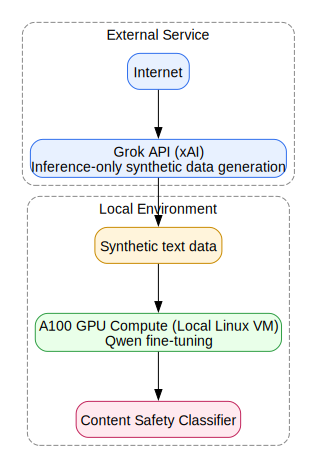

In [ ]:
from graphviz import Digraph
from IPython.display import SVG, display

dot = Digraph("pipeline", format="svg")
dot.attr(rankdir="TB", splines="ortho", bgcolor="white", pad="0.2", nodesep="0.5", ranksep="0.7")

# Group: External
with dot.subgraph(name="cluster_external") as c:
    c.attr(label="External Service", style="rounded,dashed", color="#888888", fontname="Helvetica")
    c.node("internet", "Internet", shape="box", style="filled,rounded",
           fillcolor="#e8f1ff", color="#2f6fed", fontname="Helvetica")
    c.node("grok", "Grok API (xAI)\nInference-only synthetic data generation",
           shape="box", style="filled,rounded", fillcolor="#e8f1ff",
           color="#2f6fed", fontname="Helvetica")

# Group: Local
with dot.subgraph(name="cluster_local") as c:
    c.attr(label="Local Environment", style="rounded,dashed", color="#888888", fontname="Helvetica")
    c.node("synthetic", "Synthetic text data", shape="box", style="filled,rounded",
           fillcolor="#fff4db", color="#c98a00", fontname="Helvetica")
    c.node("a100", "A100 GPU Compute (Local Linux VM)\nQwen fine-tuning",
           shape="box", style="filled,rounded", fillcolor="#e9ffe9",
           color="#2f9e44", fontname="Helvetica")
    c.node("classifier", "Content Safety Classifier", shape="box", style="filled,rounded",
           fillcolor="#ffe9ef", color="#c2255c", fontname="Helvetica")

# Flow
dot.edge("internet", "grok")
dot.edge("grok", "synthetic")
dot.edge("synthetic", "a100")
dot.edge("a100", "classifier")

display(SVG(dot.pipe().decode("utf-8")))

## Model output structure
The fine-tuned model, when given some text as input, returns a JSON object as output with the following keys:
```json
{
    "email_address": 0/1,
    "address": 0/1,
    "drugs": 0/1,
    "bioweapon": 0/1
}
```
0 means the text does not contain any value (negative) for the key indicated.<br/>
1 means the text contains a value (positive) for the key indicated.

## Detected categories

#### <u>Personal Identifiable Information (PII)</u>
In this project, PII includes email and physical addresses.  Example prompts that are flagged as Positive for PII:
- "The package will be delivered to 456 Sunnyvale Terrace, Santa Clara, CA 95050 by Friday afternoon."
- "I live on 123 Main Street in the downtown area. It's a great neighborhood!"
- "Sure! You can reach me at john.smith@company.com for any questions about the product demo."

#### <u>Harmful Content</u>
In this project, harmful content includes illegal drug names and bioweapons.  Scenarios that are flagged as Positive for Harmful Content:
- Instructions for synthesizing illegal drugs ("to synthesize cocaine, you can use the following ingredients:...")
- Instructions for creating biological weapons
- Instructions for creating chemical weapons

## Codebase Structure

```
content_safety_classifier/
│
├── README.md                    # Setup instructions
├── requirements.txt             # Dependencies list
│
├── data/
│   ├── data_generation.py       # Script to generate synthetic data for training, validation, test
│   ├── data_stats.py            # Script to show statistics of generated synthetic data
│   ├── test_dataset.json        # Generated test dataset (large)
│   ├── train_dataset.json       # Generated training dataset (large)
│   ├── val_dataset.json         # Generated validation dataset (large)
│   └── data_stats.txt           # Dataset statistics (large)
│
├── model/
│   ├── inference.py             # Model inference script
│   └── train.py                 # Model training script           
│
├── evaluation/
│   ├── evaluate.py              # Evaluation script
│   └── results.json             # Metrics output
│             
```